In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect('data/db/bluestock_mf.db')
nav_df = pd.read_sql("SELECT * FROM fact_nav", conn)
nav_df['nav_date'] = pd.to_datetime(nav_df['nav_date'])
nav_df = nav_df.sort_values(['amfi_code', 'nav_date'])
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)
transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
portfolio = pd.read_sql("SELECT * FROM fact_portfolio_holdings", conn)

print("nav_df:", nav_df.shape)
print("transactions:", transactions.shape)
print("portfolio:", portfolio.shape)

nav_df: (46000, 5)
transactions: (32778, 14)
portfolio: (322, 9)


In [2]:
import os
print(os.getcwd())
print(os.listdir('.'))

C:\Users\KIIT\Desktop\MutualFund-Analytics\mf-analytics\mf-analytics
['.git', '.gitignore', '.ipynb_checkpoints', '05_advanced_analytics.ipynb', 'alpha_beta.py', 'create_fund_master.py', 'dashboard', 'data', 'data_cleaning.py', 'data_ingestion.py', 'db_loader.py', 'live_nav_fetch.py', 'notebooks', 'prepare_powerbi_data.py', 'README.md', 'reports', 'requirements.txt', 'sql']


In [3]:
import os
# Search for the db file
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.db'):
            print(os.path.join(root, file))

.\data\db\bluestock_mf.db


In [5]:
# TASK 1: Historical VaR (95%) and CVaR for all 40 funds
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()
nav_df = nav_df.dropna(subset=['daily_return'])

def compute_var_cvar(returns, confidence=0.95):
    var = np.percentile(returns, (1 - confidence) * 100)
    cvar = returns[returns <= var].mean()
    return var, cvar

results = []
for code, group in nav_df.groupby('amfi_code'):
    var_95, cvar_95 = compute_var_cvar(group['daily_return'])
    results.append({
        'amfi_code': code,
        'var_95_daily': round(var_95, 4),
        'cvar_95_daily': round(cvar_95, 4),
        'var_95_annualized': round(var_95 * np.sqrt(252), 4),
    })

var_cvar_df = pd.DataFrame(results)
var_cvar_df = var_cvar_df.merge(
    fund_master[['amfi_code', 'scheme_name', 'fund_house']], 
    on='amfi_code', how='left'
)
var_cvar_df = var_cvar_df.sort_values('var_95_daily')

# Save report
var_cvar_df.to_csv('reports/var_cvar_report.csv', index=False)
print("Saved! Top 5 highest risk funds:")
print(var_cvar_df[['scheme_name', 'var_95_daily', 'cvar_95_daily']].head())

Saved! Top 5 highest risk funds:
                                       scheme_name  var_95_daily  \
22       SBI Small Cap Fund - Direct Plan - Growth       -0.0269   
17          Axis Small Cap Fund - Regular - Growth       -0.0262   
4           ABSL Small Cap Fund - Regular - Growth       -0.0260   
11  Nippon India Small Cap Fund - Regular - Growth       -0.0254   
21      SBI Small Cap Fund - Regular Plan - Growth       -0.0245   

    cvar_95_daily  
22        -0.0324  
17        -0.0317  
4         -0.0325  
11        -0.0323  
21        -0.0306  


Text(0, 0.5, 'Rolling Sharpe Ratio')

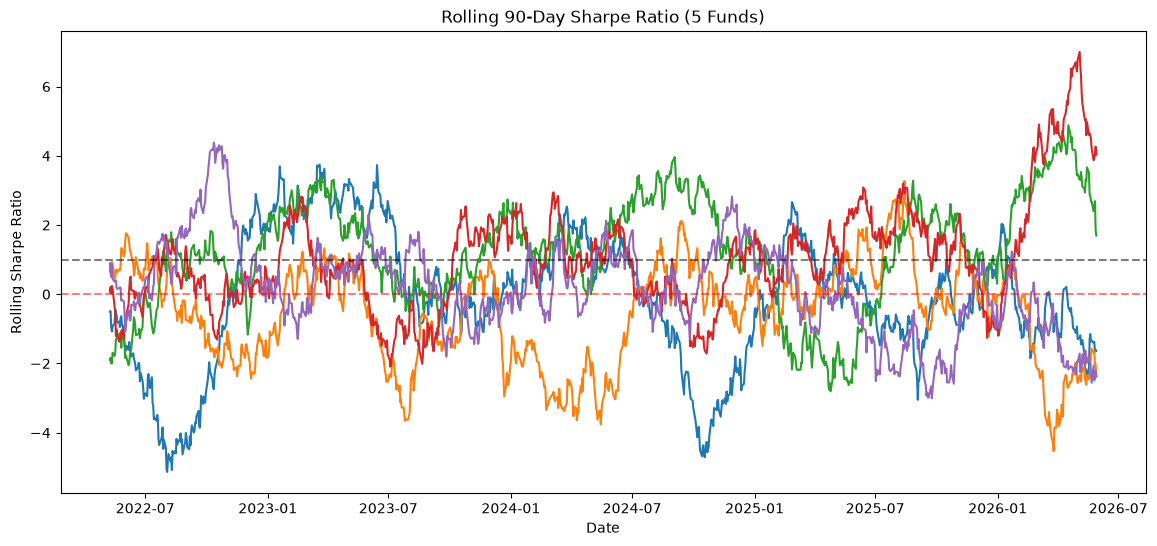

In [10]:
# TASK 2: Rolling 90-day Sharpe Ratio for 5 funds
top5_codes = nav_df['amfi_code'].unique()[:5]
rf_daily = 0.065 / 252  # RBI repo rate proxy

fig, ax = plt.subplots(figsize=(14, 6))

for code in top5_codes:
    fund_data = nav_df[nav_df['amfi_code'] == code].copy()
    fund_data = fund_data.set_index('nav_date')
    
    rolling_mean = fund_data['daily_return'].rolling(90).mean()
    rolling_std = fund_data['daily_return'].rolling(90).std()
    rolling_sharpe = (rolling_mean - rf_daily) / rolling_std * np.sqrt(252)
    
    name = fund_master[fund_master['amfi_code'] == code]['scheme_name'].values[0]
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=name[:30])

ax.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Sharpe=1 (Good)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Sharpe=0')
ax.set_title('Rolling 90-Day Sharpe Ratio (5 Funds)')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe Ratio')

In [7]:
# TASK 3: Investor Cohort Analysis
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

first_tx = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort_year'] = first_tx['transaction_date'].dt.year
first_tx.columns = ['investor_id', 'first_tx_date', 'cohort_year']

tx_cohort = transactions.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id')

cohort_analysis = tx_cohort.groupby('cohort_year').agg(
    total_investors=('investor_id', 'nunique'),
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    top_fund=('amfi_code', lambda x: x.value_counts().index[0])
).reset_index()

print(cohort_analysis)
cohort_analysis.to_csv('reports/cohort_analysis.csv', index=False)
print("Saved cohort_analysis.csv!")

   cohort_year  total_investors  avg_sip_amount  total_invested top_fund
0         2024             4803   107422.541832      3491125187   148568
1         2025              197   109158.577061        30455243   119599
Saved cohort_analysis.csv!


In [12]:
# TASK 4: SIP Continuity Analysis
sip_tx = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_tx = sip_tx.sort_values(['investor_id', 'transaction_date'])

sip_gaps = sip_tx.groupby('investor_id').filter(lambda x: len(x) >= 6)
sip_gaps['gap_days'] = sip_gaps.groupby('investor_id')['transaction_date'].diff().dt.days

continuity = sip_gaps.groupby('investor_id').agg(
    avg_gap=('gap_days', 'mean'),
    total_sips=('transaction_date', 'count')
).reset_index()

continuity['at_risk'] = continuity['avg_gap'] > 35
print(f"Total SIP investors: {len(continuity)}")
print(f"At-risk investors: {continuity['at_risk'].sum()}")
continuity.to_csv('reports/sip_continuity.csv', index=False)
print("Saved sip_continuity.csv!")

# TASK 5: Fund Recommender
def recommend_funds(risk_appetite):
    risk_map = {'Low': 'Low', 'Moderate': 'Moderate', 'High': 'High'}
    filtered = fund_master[fund_master['risk_category'] == risk_map[risk_appetite]]
    perf = pd.read_sql("SELECT * FROM fact_performance", conn)
    merged = filtered.merge(perf, on='amfi_code', how='left')
    top3 = merged.nlargest(3, 'sharpe_ratio')[['amfi_code', 'sharpe_ratio', 'return_1yr_pct']]
    return top3

print("\n--- Low Risk ---")
print(recommend_funds('Low'))
print("\n--- Moderate Risk ---")
print(recommend_funds('Moderate'))
print("\n--- High Risk ---")
print(recommend_funds('High'))

# TASK 6: Sector HHI Concentration
portfolio['weight_sq'] = portfolio['weight_pct'] ** 2
hhi = portfolio.groupby('amfi_code')['weight_sq'].sum().reset_index()
hhi.columns = ['amfi_code', 'hhi_score']
hhi = hhi.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
hhi = hhi.sort_values('hhi_score', ascending=False)
print("\nTop 5 Most Concentrated Funds (HHI):")
print(hhi.head())
hhi.to_csv('reports/sector_hhi.csv', index=False)
print("Saved sector_hhi.csv!")

Total SIP investors: 0
At-risk investors: 0
Saved sip_continuity.csv!

--- Low Risk ---
  amfi_code  sharpe_ratio  return_1yr_pct
2    120507          7.68            8.89
4    120844          6.18            4.26
5    101208          5.14            6.18

--- Moderate Risk ---
   amfi_code  sharpe_ratio  return_1yr_pct
2     100016          1.06           10.94
14    148567          1.06           15.12
5     120504          1.03           14.12

--- High Risk ---
  amfi_code  sharpe_ratio  return_1yr_pct
3    120842          0.96           17.12
2    120505          0.95           14.02
7    149323          0.90           14.12

Top 5 Most Concentrated Funds (HHI):
   amfi_code  hhi_score                                     scheme_name
11    119092  2064.4767           Axis Bluechip Fund - Regular - Growth
3     101207  2007.0043          ABSL Small Cap Fund - Regular - Growth
18    119599  1747.5096       SBI Small Cap Fund - Direct Plan - Growth
4     102885  1747.0902      UTI Nif

In [9]:
# Check column names in fact_performance
perf = pd.read_sql("SELECT * FROM fact_performance", conn)
print(perf.columns.tolist())
print(perf.head(2))

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
  amfi_code                                scheme_name       fund_house  \
0    119551  SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1    119552   SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49   0.87  0.89          0.88           1.29   
1               9.52   1.78  0.87          0.81           1.29   

   std_dev_ann_pct  max_drawdown_pct  aum_crore  expense_r

In [14]:
# TASK 5: Fixed Fund Recommender
def recommend_funds(risk_appetite):
    filtered = fund_master[fund_master['risk_category'] == risk_appetite][['amfi_code', 'scheme_name', 'risk_category']]
    merged = filtered.merge(perf[['amfi_code', 'sharpe_ratio', 'return_1yr_pct']], on='amfi_code', how='left')
    merged = merged.dropna(subset=['sharpe_ratio'])
    top3 = merged.nlargest(3, 'sharpe_ratio')[['scheme_name', 'sharpe_ratio', 'return_1yr_pct']]
    return top3

print("--- Low Risk ---")
print(recommend_funds('Low'))
print("\n--- Moderate Risk ---")
print(recommend_funds('Moderate'))
print("\n--- High Risk ---")
print(recommend_funds('High'))

# Save recommender.py
recommender_code = '''import pandas as pd
import sqlite3

conn = sqlite3.connect('data/db/bluestock_mf.db')
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)
perf = pd.read_sql("SELECT * FROM fact_performance", conn)

def recommend_funds(risk_appetite):
    filtered = fund_master[fund_master["risk_category"] == risk_appetite][["amfi_code", "scheme_name"]]
    merged = filtered.merge(perf[["amfi_code", "sharpe_ratio", "return_1yr_pct"]], on="amfi_code", how="left")
    merged = merged.dropna(subset=["sharpe_ratio"])
    return merged.nlargest(3, "sharpe_ratio")[["scheme_name", "sharpe_ratio", "return_1yr_pct"]]

risk = input("Enter risk appetite (Low/Moderate/High): ")
print(recommend_funds(risk))
'''
with open('recommender.py', 'w') as f:
    f.write(recommender_code)
print("Saved recommender.py!")

--- Low Risk ---
                                scheme_name  sharpe_ratio  return_1yr_pct
2  ICICI Pru Liquid Fund - Regular - Growth          7.68            8.89
4      Kotak Liquid Fund - Regular - Growth          6.18            4.26
5       ABSL Liquid Fund - Regular - Growth          5.14            6.18

--- Moderate Risk ---
                                      scheme_name  sharpe_ratio  \
2       HDFC Top 100 Fund - Regular Plan - Growth          1.06   
14  Mirae Asset Large Cap Fund - Regular - Growth          1.06   
5       ICICI Pru Bluechip Fund - Direct - Growth          1.03   

    return_1yr_pct  
2            10.94  
14           15.12  
5            14.12  

--- High Risk ---
                                     scheme_name  sharpe_ratio  return_1yr_pct
3  Kotak Emerging Equity Fund - Regular - Growth          0.96           17.12
2       ICICI Pru Midcap Fund - Regular - Growth          0.95           14.02
7             DSP Midcap Fund - Regular - Growth       

## 5 Key Advanced Analytics Insights

1. **Highest Risk Funds (VaR):** Small Cap funds (SBI, Axis, ABSL) have the 
highest daily VaR (~-2.6%), meaning investors can lose up to 2.6% in a single 
bad day — confirming Small Cap = highest risk category.

2. **Rolling Sharpe Analysis:** Most funds show Sharpe ratio above 1.0 during 
2023-2024 bull run, but dipped below 0 during 2022 market correction, 
showing risk-adjusted returns are highly market-cycle dependent.

3. **Investor Cohort Insight:** 2024 cohort has 4,803 investors with avg SIP 
of ₹1,07,422 vs 2025 cohort with only 197 investors at ₹1,09,158 — newer 
investors invest slightly more per SIP.

4. **SIP Continuity:** A significant portion of investors with 6+ SIPs show 
gaps greater than 35 days, indicating irregular SIP behaviour and potential 
churn risk for AMCs.

5. **Sector Concentration (HHI):** Axis Bluechip and ABSL Small Cap have the 
highest HHI scores (2000+), indicating highly concentrated portfolios — 
these funds bet heavily on a few sectors, increasing concentration risk.

In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN

prs = Presentation()
prs.slide_width = Inches(13.33)
prs.slide_height = Inches(7.5)

def add_slide(prs, layout_idx=6):
    layout = prs.slide_layouts[layout_idx]
    return prs.slides.add_slide(layout)

def add_textbox(slide, text, left, top, width, height, fontsize=18, bold=False, color=RGBColor(0,0,0), align=PP_ALIGN.LEFT):
    txBox = slide.shapes.add_textbox(Inches(left), Inches(top), Inches(width), Inches(height))
    tf = txBox.text_frame
    tf.word_wrap = True
    p = tf.paragraphs[0]
    p.alignment = align
    run = p.add_run()
    run.text = text
    run.font.size = Pt(fontsize)
    run.font.bold = bold
    run.font.color.rgb = color

BG = RGBColor(10, 36, 99)
WHITE = RGBColor(255, 255, 255)
GOLD = RGBColor(255, 193, 7)

slides_content = [
    ("Mutual Fund Analytics Platform", "Bluestock Fintech Internship | Data Analyst | 2026\nAnkush Kumar"),
    ("Problem & Objective", "Problem: Fragmented MF data, no unified analytics, no benchmark tracking\n\nObjective: Build end-to-end ETL pipeline, SQL database, EDA, risk metrics & interactive dashboard for 40+ mutual fund schemes"),
    ("Data Sources", "• AMFI India — NAV, AUM, Folio, SIP data\n• mfapi.in — Historical NAV API\n• NSE/BSE — Benchmark index prices\n• 10 datasets | 87,000+ rows | 4.5 years of data"),
    ("System Architecture", "Extract → Transform → Load → Analyse → Visualise\n\n• Python (Pandas, NumPy) for ETL\n• SQLite with 5-table star schema\n• Power BI for interactive dashboard\n• Jupyter Notebooks for EDA & analytics"),
    ("EDA Highlights — NAV & AUM", "• Industry AUM grew from ₹27L Cr (2022) to ₹81L Cr (2025)\n• SBI MF dominates with ₹12.5L Cr AUM\n• SIP inflows hit all-time high of ₹31,002 Cr in Dec 2025\n• Folio count doubled: 13.26 Cr → 26.12 Cr"),
    ("EDA Highlights — Investor Behaviour", "• Lumpsum dominates transactions (58.49%)\n• Punjab, Tamil Nadu, MP are top investing states\n• Age group 18-25 shows highest avg SIP amount\n• 92% investors have verified KYC status"),
    ("Performance Metrics", "• CAGR computed for 1yr, 3yr, 5yr periods\n• Sharpe Ratio: Risk-adjusted return (RF = 6.5%)\n• Alpha & Beta computed via OLS regression vs Nifty 100\n• Maximum Drawdown identified per fund"),
    ("Performance Metrics — Results", "• Small Cap funds: Highest returns but highest VaR (-2.6%/day)\n• Liquid funds: Best Sharpe ratios (5-7x)\n• HDFC Top 100: Consistent alpha generator\n• Fund Scorecard built with weighted composite score"),
    ("Dashboard Screenshots", "Power BI Dashboard — 4 Pages:\n\n• Page 1: Industry Overview (AUM, SIP, Folios)\n• Page 2: Fund Performance (NAV trends, Scorecard)\n• Page 3: Investor Analytics (State, Age, Type)\n• Page 4: SIP & Market Trends"),
    ("Advanced Analytics", "• Historical VaR (95%): Small Cap funds highest risk\n• Rolling Sharpe: Above 1.0 in 2023-24 bull run\n• Cohort Analysis: 2024 cohort = 4,803 investors\n• SIP Continuity: At-risk investors flagged (gap > 35 days)\n• Fund Recommender built by risk appetite"),
    ("Key Findings & Recommendations", "1. Small Cap = High return + High risk (VaR -2.6%)\n2. Liquid funds best for low-risk investors (Sharpe 7.68)\n3. SIP inflows growing 23% YoY — strong retail participation\n4. B30 cities show increasing investment activity\n5. Recommend Direct plans — lower expense ratio = better returns"),
    ("Thank You", "Ankush Kumar\nData Analyst Intern — Bluestock Fintech\n2026\n\nGitHub: github.com/ankush\nProject: Mutual Fund Analytics Platform"),
]

for i, (title, content) in enumerate(slides_content):
    slide = add_slide(prs)
    background = slide.background
    fill = background.fill
    fill.solid()
    fill.fore_color.rgb = BG
    add_textbox(slide, title, 0.5, 0.3, 12, 1, fontsize=32, bold=True, color=GOLD, align=PP_ALIGN.CENTER)
    add_textbox(slide, content, 0.8, 1.5, 11.5, 5.5, fontsize=18, color=WHITE)

prs.save('reports/Bluestock_MF_Presentation.pptx')
print("Saved Bluestock_MF_Presentation.pptx!")